# Phase 3 (notebook 03) — diagnostic + GR-template correlation

**What we learned in 02.** A (carry-forward) won decisively at pooled RMSE 15.9, while B (Z-shift) and
C (linear-MD) landed at ~110. The reading: these wells are *geosteered* — the driller actively keeps the
bit inside the target formation, so TVT (depth-relative-to-formation) stays approximately constant across
the lateral while wellbore Z wobbles around it. Carry-forward implicitly assumes constant TVT and gets
rewarded; geometry-based methods inherit Z's wobble as prediction error.

**This notebook:**
1. **Diagnostic.** Visualize where carry-forward fails — what do high-RMSE wells look like? Is GR signaling
   the formation transitions?
2. **Baseline D — smoothed anchor.** Cheap variant: instead of the single last known TVT as the anchor, use
   the mean of the last K known TVT values. K-sweep, see if it moves the needle.
3. **Baseline E — GR template correlation.** The geosteering classic. For each eval row, take a window of
   lateral GR around it; find the TVT in the typewell whose GR window best matches; constrain the search to
   within ±R of the carry-forward anchor; smooth the per-row predictions to avoid jitter.
4. **Compare + submit** if anything beats A.

**Harness change.** Old harness was `predict_fn(g)`. New harness is `predict_fn(g, tw)` so methods can use
the typewell. Old baselines (A, B, C) are redefined with the new signature; they just ignore `tw`.

## 0. Setup

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

ROOT = Path('..').resolve()
DATA = ROOT / 'data'
TRAIN_DIR = DATA / 'train'
TEST_DIR  = DATA / 'test'
CACHE_DIR = ROOT / 'cache';        CACHE_DIR.mkdir(exist_ok=True)
SUB_DIR   = ROOT / 'submissions';  SUB_DIR.mkdir(exist_ok=True)

COL_MD, COL_X, COL_Y, COL_Z = 'MD', 'X', 'Y', 'Z'
COL_GR = 'GR'
COL_TVT_INPUT = 'TVT_input'
COL_TVT       = 'TVT'

print(f'Project root: {ROOT}')

Project root: /home/gokhuu/portfolio/ROGII-Wellbore


## 1. Reload caches + updated harness

- `train_df`: re-uses the pickle from notebook 02 (`cache/train_wells.pkl`).
- `train_tw`: new — a dict mapping `well -> typewell DataFrame`. First run reads 773 typewell CSVs
  (~10-30s) and pickles them. Re-runs are instant.

In [2]:
TRAIN_HW_CACHE = CACHE_DIR / 'train_wells.pkl'
TRAIN_TW_CACHE = CACHE_DIR / 'train_typewells.pkl'

def load_train_wells(force_reload: bool = False) -> pd.DataFrame:
    if TRAIN_HW_CACHE.exists() and not force_reload:
        df = pd.read_pickle(TRAIN_HW_CACHE)
        print(f'Loaded HW cache: {df.shape}')
        return df
    print('Reading 773 horizontal-well CSVs...')
    frames = []
    for f in sorted(TRAIN_DIR.glob('*__horizontal_well.csv')):
        well = f.name.replace('__horizontal_well.csv', '')
        d = pd.read_csv(f)
        d['well'] = well
        d['row_idx'] = np.arange(len(d), dtype=np.int32)
        frames.append(d)
    df = pd.concat(frames, ignore_index=True)
    df.to_pickle(TRAIN_HW_CACHE)
    return df

def load_train_typewells(force_reload: bool = False) -> dict:
    if TRAIN_TW_CACHE.exists() and not force_reload:
        d = pd.read_pickle(TRAIN_TW_CACHE)
        print(f'Loaded TW cache: {len(d)} typewells')
        return d
    print('Reading 773 typewell CSVs...')
    out = {}
    for f in sorted(TRAIN_DIR.glob('*__typewell.csv')):
        well = f.name.replace('__typewell.csv', '')
        out[well] = pd.read_csv(f)
    pd.to_pickle(out, TRAIN_TW_CACHE)
    print(f'Cached {len(out)} typewells -> {TRAIN_TW_CACHE.name}')
    return out

train_df = load_train_wells()
train_tw = load_train_typewells()
print(f'\nWells in train_df: {train_df["well"].nunique()}  |  typewells loaded: {len(train_tw)}')

Loaded HW cache: (5092255, 15)
Reading 773 typewell CSVs...
Cached 773 typewells -> train_typewells.pkl

Wells in train_df: 773  |  typewells loaded: 773


### Updated harness: `predict_fn(g, tw)`

Same contract as before — return predictions for all rows of the well — but `tw` (the well's typewell
DataFrame) is now passed alongside. Methods that don't need it just ignore the second arg.

In [3]:
def evaluate_baseline(
    predict_fn,
    train_df: pd.DataFrame,
    typewells: dict,
    label: str = '',
    progress: int = 0,
) -> tuple[pd.DataFrame, float]:
    """Score a baseline. predict_fn(g, tw) -> array of length len(g)."""
    rows = []
    sse_total = 0.0
    n_total   = 0
    for i, (well, g) in enumerate(train_df.groupby('well', sort=False)):
        if progress and i and i % progress == 0:
            print(f'  ... {i} wells', flush=True)
        eval_mask = g[COL_TVT_INPUT].isna().values
        if not eval_mask.any():
            continue
        truth = g.loc[eval_mask, COL_TVT].values
        tw    = typewells.get(well)
        pred  = np.asarray(predict_fn(g, tw), dtype=float)
        if pred.shape[0] != len(g):
            raise ValueError(f'predict_fn returned {pred.shape[0]} preds for well {well} of length {len(g)}')
        diff = pred[eval_mask] - truth
        sq = diff ** 2
        rows.append({
            'well': well,
            'rmse': float(np.sqrt(sq.mean())),
            'n_eval': int(eval_mask.sum()),
            'mae': float(np.abs(diff).mean()),
            'max_err': float(np.abs(diff).max()),
        })
        sse_total += float(sq.sum())
        n_total   += int(len(sq))
    res = pd.DataFrame(rows)
    pooled = float(np.sqrt(sse_total / n_total)) if n_total else float('nan')
    if label:
        print(f'{label:35s}  pooled RMSE = {pooled:8.3f}   '
              f'per-well: median={res["rmse"].median():7.2f}, '
              f'mean={res["rmse"].mean():7.2f}, '
              f'p90={res["rmse"].quantile(.9):7.2f}, '
              f'max={res["rmse"].max():7.2f}')
    return res, pooled

### Re-evaluate the 02 baselines under the new signature

Sanity check: numbers should match notebook 02 exactly.

In [4]:
def predict_carry_forward(g, tw=None):
    return g[COL_TVT_INPUT].ffill().bfill().values.astype(float)

def predict_z_shift(g, tw=None):
    pred = g[COL_TVT_INPUT].values.astype(float).copy()
    eval_mask = np.isnan(pred)
    if not eval_mask.any(): return pred
    known_idx = np.where(~eval_mask)[0]
    if len(known_idx) == 0: return g[COL_Z].values.astype(float)
    last_k = known_idx[-1]
    z_vals = g[COL_Z].values
    offset = pred[last_k] - z_vals[last_k]
    pred[eval_mask] = z_vals[eval_mask] + offset
    return pred

def make_linear_extrap_md(K: int):
    def predict(g, tw=None):
        pred = g[COL_TVT_INPUT].values.astype(float).copy()
        eval_mask = np.isnan(pred)
        if not eval_mask.any(): return pred
        known_idx = np.where(~eval_mask)[0]
        if len(known_idx) < 2:
            if len(known_idx) == 1: pred[eval_mask] = pred[known_idx[0]]
            return pred
        idx_fit = known_idx[-K:] if len(known_idx) >= K else known_idx
        slope, intercept = np.polyfit(g[COL_MD].values[idx_fit], pred[idx_fit], 1)
        pred[eval_mask] = slope * g[COL_MD].values[eval_mask] + intercept
        return pred
    return predict

res_A, rmse_A = evaluate_baseline(predict_carry_forward,        train_df, train_tw, 'A. carry-forward')
res_B, rmse_B = evaluate_baseline(predict_z_shift,               train_df, train_tw, 'B. Z-shift')
res_C, rmse_C = evaluate_baseline(make_linear_extrap_md(20),     train_df, train_tw, 'C. linear MD K=20')

A. carry-forward                     pooled RMSE =   15.910   per-well: median=  10.67, mean=  12.81, p90=  22.97, max=  70.64
B. Z-shift                           pooled RMSE =  111.319   per-well: median=  94.68, mean=  97.35, p90= 150.74, max= 263.35
C. linear MD K=20                    pooled RMSE =  107.771   per-well: median=  37.71, mean=  58.72, p90= 128.29, max=1332.39


## 2. Diagnose A — what do the failure cases look like?

Pick a few wells across the spectrum of A's per-well RMSE and visualize: TVT trajectory (known + true eval +
carry-forward prediction), lateral GR, typewell GR. The question we want answered: do the high-RMSE wells
show GR patterns that *would* let us detect TVT changes — i.e., is GR-correlation worth pursuing?

In [5]:
# Pick wells: best, median, 90th percentile, worst
sorted_A = res_A.sort_values('rmse').reset_index(drop=True)
n = len(sorted_A)
picks = [
    ('best',     sorted_A.iloc[0]['well'],            sorted_A.iloc[0]['rmse']),
    ('median',   sorted_A.iloc[n // 2]['well'],       sorted_A.iloc[n // 2]['rmse']),
    ('p90',      sorted_A.iloc[int(n * 0.9)]['well'], sorted_A.iloc[int(n * 0.9)]['rmse']),
    ('worst',    sorted_A.iloc[-1]['well'],           sorted_A.iloc[-1]['rmse']),
]
print('Wells selected for diagnostic:')
for tag, w, r in picks: print(f'  {tag:8s}  {w}  (A RMSE = {r:.2f})')

Wells selected for diagnostic:
  best      283269ac  (A RMSE = 1.12)
  median    2cee0cba  (A RMSE = 10.67)
  p90       42669188  (A RMSE = 23.03)
  worst     1b1eba53  (A RMSE = 70.64)


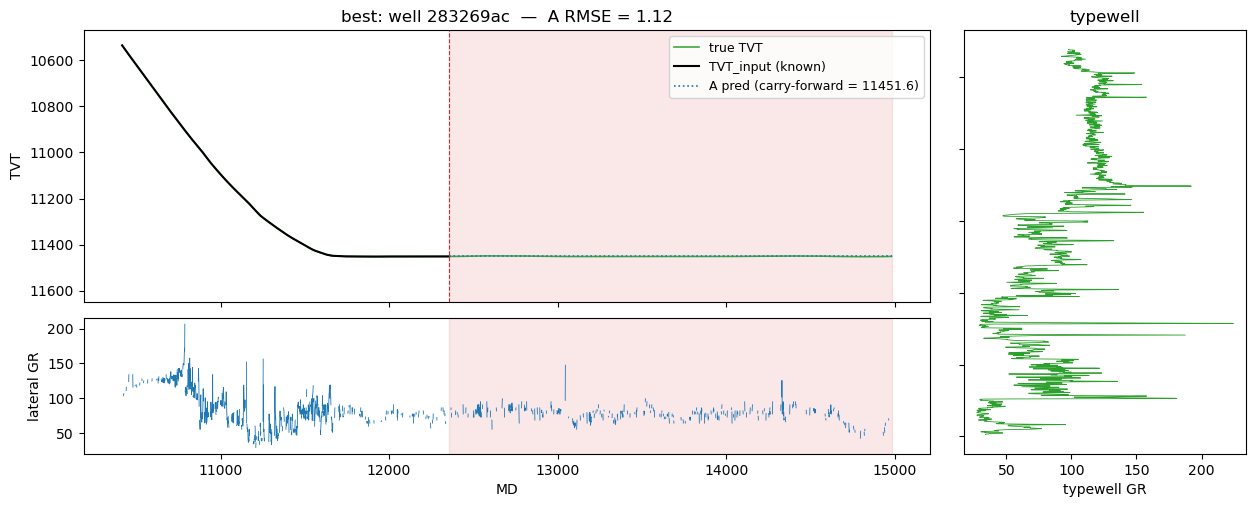

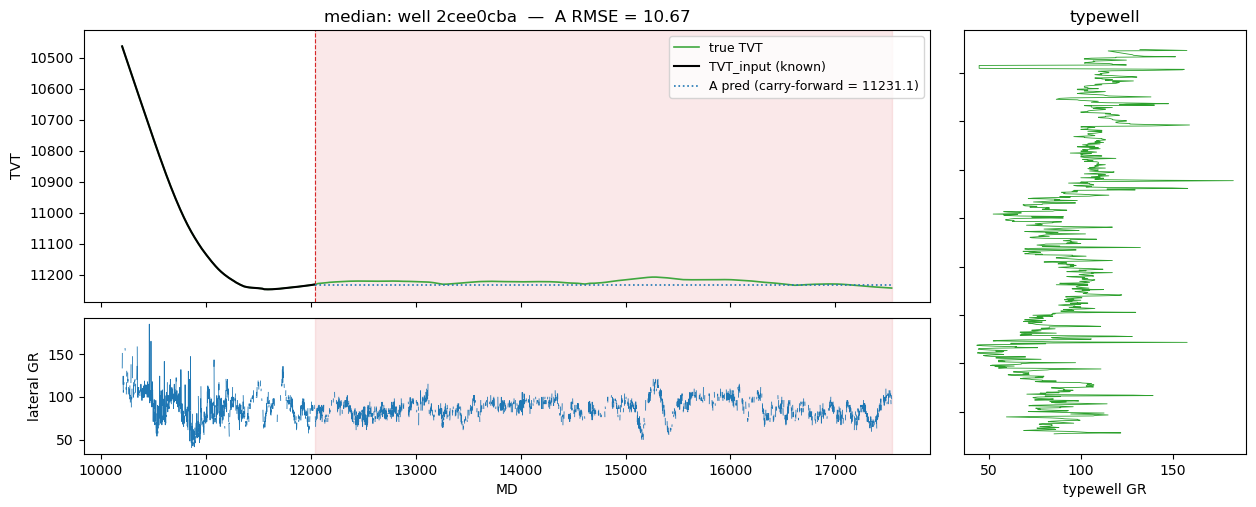

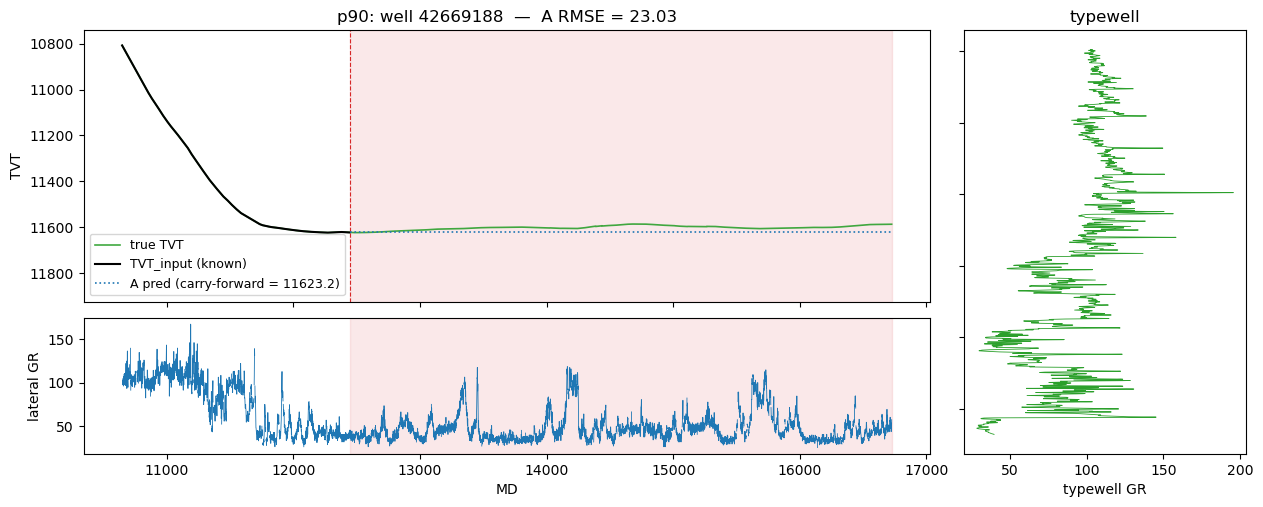

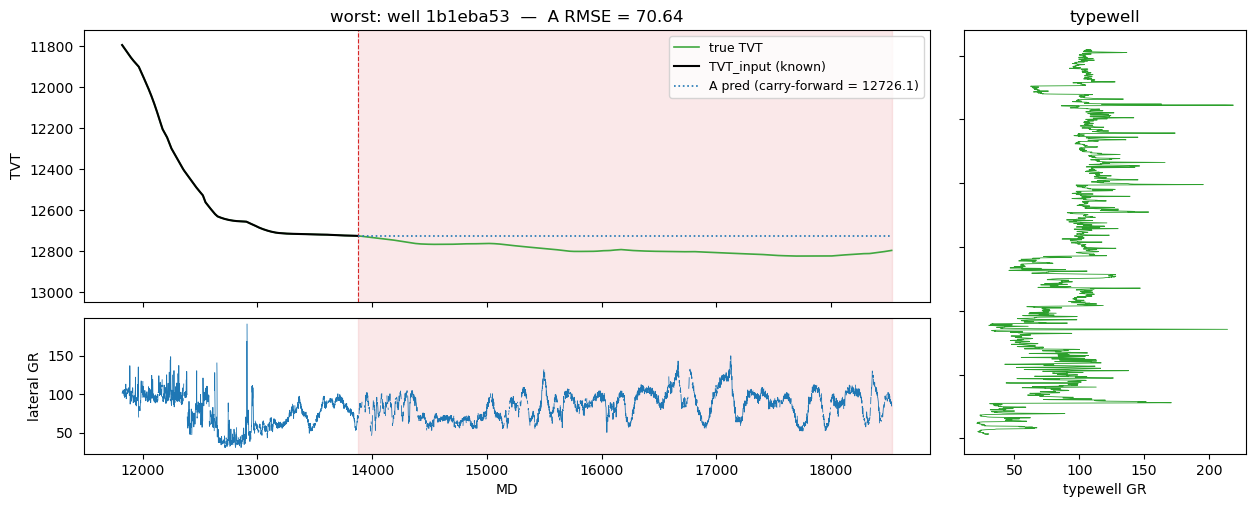

In [6]:
def plot_diagnostic(well: str, tag: str, rmse: float, train_df, train_tw):
    g  = train_df[train_df['well'] == well].reset_index(drop=True)
    tw = train_tw.get(well)
    md = g[COL_MD].values
    gr = g[COL_GR].values
    tvt_in   = g[COL_TVT_INPUT].values
    tvt_true = g[COL_TVT].values
    eval_mask = np.isnan(tvt_in)
    eval_idx = np.where(eval_mask)[0]
    known_idx = np.where(~eval_mask)[0]
    anchor = tvt_in[known_idx[-1]] if len(known_idx) else np.nan

    fig = plt.figure(figsize=(15, 5.5))
    gs = fig.add_gridspec(2, 2, width_ratios=[3, 1], height_ratios=[2, 1], hspace=0.08, wspace=0.06)
    ax_tvt = fig.add_subplot(gs[0, 0])
    ax_gr  = fig.add_subplot(gs[1, 0], sharex=ax_tvt)
    ax_tw  = fig.add_subplot(gs[:, 1], sharey=ax_tvt)

    # TVT panel
    ax_tvt.plot(md, tvt_true, color='C2', lw=1.2, label='true TVT', alpha=0.9)
    ax_tvt.plot(md[~eval_mask], tvt_in[~eval_mask], color='k', lw=1.5, label='TVT_input (known)')
    if eval_idx.size:
        ax_tvt.axvspan(md[eval_idx[0]], md[eval_idx[-1]], alpha=0.10, color='C3')
        ax_tvt.axvline(md[eval_idx[0]], color='C3', ls='--', lw=0.8)
        ax_tvt.hlines(anchor, md[eval_idx[0]], md[eval_idx[-1]],
                      color='C0', lw=1.2, ls=':', label=f'A pred (carry-forward = {anchor:.1f})')
    ax_tvt.invert_yaxis()
    ax_tvt.set_ylabel('TVT'); ax_tvt.legend(loc='best', fontsize=9)
    ax_tvt.set_title(f'{tag}: well {well}  —  A RMSE = {rmse:.2f}')
    ax_tvt.tick_params(labelbottom=False)

    # GR panel
    ax_gr.plot(md, gr, color='C0', lw=0.6)
    if eval_idx.size:
        ax_gr.axvspan(md[eval_idx[0]], md[eval_idx[-1]], alpha=0.10, color='C3')
    ax_gr.set_xlabel('MD'); ax_gr.set_ylabel('lateral GR')

    # Typewell panel (TVT-axis aligned to lateral panel via sharey)
    if tw is not None and COL_GR in tw and COL_TVT in tw:
        ax_tw.plot(tw[COL_GR].values, tw[COL_TVT].values, color='C2', lw=0.6)
        ax_tw.set_xlabel('typewell GR'); ax_tw.set_title('typewell')
        ax_tw.tick_params(labelleft=False)
    else:
        ax_tw.text(0.5, 0.5, '(no typewell)', ha='center', va='center',
                   transform=ax_tw.transAxes); ax_tw.set_xticks([]); ax_tw.set_yticks([])

    plt.show()

for tag, well, rmse in picks:
    plot_diagnostic(well, tag, rmse, train_df, train_tw)

**What to look for in the plots above:**
- The shaded region is the eval zone. The black line is `TVT_input` (known), green is true `TVT`, dotted
  blue is carry-forward's flat prediction.
- For low-RMSE wells, the green line should be roughly flat through the eval zone — TVT really is constant
  and carry-forward nails it.
- For the worst wells, you should see the green TVT trace deviating from the dotted blue line — that's the
  error A is making. Compare the GR panel below: if formation transitions show up as GR-character changes
  at roughly the same MD where TVT diverges, that's evidence GR-correlation could detect them.
- The right panel shows the typewell GR-vs-TVT. The TVT axis is shared with the lateral panel, so you can
  visually correlate: at any TVT in the eval zone, what GR does the typewell predict?

## 3. Baseline D — smoothed anchor

Cheap variant: anchor = mean of last K known `TVT_input` rows, instead of the single last value. Defends
against any noise in the boundary row. Probably marginal but takes one cell to test.

In [7]:
def make_smooth_anchor(K: int):
    def predict(g, tw=None):
        pred = g[COL_TVT_INPUT].values.astype(float).copy()
        eval_mask = np.isnan(pred)
        if not eval_mask.any(): return pred
        known_idx = np.where(~eval_mask)[0]
        if len(known_idx) == 0: return pred
        anchor = pred[known_idx[-K:]].mean() if len(known_idx) >= 1 else pred[known_idx[-1]]
        pred[eval_mask] = anchor
        return pred
    return predict

K_anchor_sweep = [1, 5, 20, 50, 100, 200, 500]
anchor_results = {}
for K in K_anchor_sweep:
    res, rmse = evaluate_baseline(make_smooth_anchor(K), train_df, train_tw, f'D. smooth anchor K={K}')
    anchor_results[K] = (res, rmse)
best_K_anchor = min(anchor_results, key=lambda k: anchor_results[k][1])
res_D, rmse_D = anchor_results[best_K_anchor]
print(f'\nBest K for smoothed anchor: K={best_K_anchor}  ->  pooled RMSE {rmse_D:.3f}')

D. smooth anchor K=1                 pooled RMSE =   15.910   per-well: median=  10.67, mean=  12.81, p90=  22.97, max=  70.64
D. smooth anchor K=5                 pooled RMSE =   15.927   per-well: median=  10.65, mean=  12.82, p90=  22.94, max=  70.71
D. smooth anchor K=20                pooled RMSE =   15.994   per-well: median=  10.63, mean=  12.86, p90=  22.88, max=  70.95
D. smooth anchor K=50                pooled RMSE =   16.135   per-well: median=  10.79, mean=  12.93, p90=  23.15, max=  78.74
D. smooth anchor K=100               pooled RMSE =   16.408   per-well: median=  10.85, mean=  13.06, p90=  23.36, max=  93.25
D. smooth anchor K=200               pooled RMSE =   17.099   per-well: median=  11.08, mean=  13.34, p90=  23.92, max= 123.10
D. smooth anchor K=500               pooled RMSE =   20.442   per-well: median=  11.36, mean=  14.39, p90=  25.71, max= 219.14

Best K for smoothed anchor: K=1  ->  pooled RMSE 15.910


## 4. Baseline E — GR template correlation (the geosteering classic)

**The idea.** The typewell tells us GR(TVT) — what GR signature each depth-relative-to-formation has. The
lateral tells us GR(MD) — what GR we observe along the wellbore. If we can find a TVT for each MD where the
GR pattern matches, we know where the bit is in the geological column.

**Implementation.**
1. Per-well z-score both GR signals (typewell GR and lateral GR), since per-well GR scale varies (EDA §6).
2. Resample the typewell GR onto a uniform 1.0-step TVT grid (lateral MD is already 1.0-step).
3. For each eval row `i` in the lateral, take a window `[i-W/2, ..., i+W/2]` of normalized lateral GR.
4. Compute cosine similarity between that window and every same-sized window in the typewell GR grid.
5. Constrain candidates to TVT within ±R of the carry-forward anchor (don't jump arbitrarily across the column).
6. Pick the TVT with maximum similarity → predicted TVT for row `i`.
7. Apply a median-filter smooth (length S) across the per-row predictions to suppress jitter.

**Hyperparameters:** window `W` (window length), search radius `R` (allowed TVT distance from anchor),
smoothing length `S`. Defaults: W=51, R=50, S=11. Small sweep below to see if anything wildly different is
better.

**Edge cases handled:**
- Eval rows too close to the start/end of the well for a full window → fall back to anchor.
- Typewell with too few rows or all-NaN GR → fall back to anchor for the entire eval zone.
- All-NaN window in lateral → fall back to anchor for that row.

In [8]:
def predict_gr_match(g: pd.DataFrame, tw: pd.DataFrame,
                     window: int = 51, search_radius: float = 50.0, smooth: int = 11) -> np.ndarray:
    pred = g[COL_TVT_INPUT].values.astype(float).copy()
    eval_mask = np.isnan(pred)
    if not eval_mask.any():
        return pred
    known_idx = np.where(~eval_mask)[0]
    if len(known_idx) == 0:
        return pred
    anchor = float(pred[known_idx[-1]])
    eval_idx = np.where(eval_mask)[0]

    # --- Lateral GR: interpolate NaN, z-score per well
    lat_gr = pd.Series(g[COL_GR].values).interpolate(limit_direction='both').values.astype(float)
    if not np.isfinite(lat_gr).all():
        pred[eval_mask] = anchor
        return pred
    lat_gr_z = (lat_gr - lat_gr.mean()) / (lat_gr.std() + 1e-9)

    # --- Typewell GR: drop NaN, sort, dedupe, resample to 1.0 TVT grid, z-score
    if tw is None or COL_GR not in tw or COL_TVT not in tw:
        pred[eval_mask] = anchor
        return pred
    tw_clean = tw.dropna(subset=[COL_TVT, COL_GR]).drop_duplicates(subset=[COL_TVT]).sort_values(COL_TVT)
    if len(tw_clean) < window + 2:
        pred[eval_mask] = anchor
        return pred
    tvt_lo, tvt_hi = float(tw_clean[COL_TVT].min()), float(tw_clean[COL_TVT].max())
    tvt_grid = np.arange(np.floor(tvt_lo), np.ceil(tvt_hi) + 1, 1.0)
    if len(tvt_grid) < window + 2:
        pred[eval_mask] = anchor
        return pred
    gr_grid = np.interp(tvt_grid, tw_clean[COL_TVT].values, tw_clean[COL_GR].values)
    gr_grid_z = (gr_grid - gr_grid.mean()) / (gr_grid.std() + 1e-9)

    # --- Build typewell window matrix and normalize each row to unit length (cosine sim by dot product)
    half = window // 2
    n_tw = len(gr_grid_z)
    TW_W = np.lib.stride_tricks.sliding_window_view(gr_grid_z, window).copy()
    norms = np.linalg.norm(TW_W, axis=1, keepdims=True); norms[norms < 1e-9] = 1.0
    TW_W /= norms
    tw_centers = tvt_grid[half : n_tw - half]   # TVT at the center of each window; len == TW_W.shape[0]

    # --- Constrain candidates to within ±R of anchor
    cand_mask = np.abs(tw_centers - anchor) <= search_radius
    if not cand_mask.any():
        pred[eval_mask] = anchor
        return pred

    # --- Build lateral window matrix for eval rows that have a full window
    n_lat = len(lat_gr_z)
    LAT_W_all = np.lib.stride_tricks.sliding_window_view(lat_gr_z, window)   # (n_lat - window + 1, window)
    in_bounds = (eval_idx >= half) & (eval_idx <= n_lat - half - 1)
    pred[eval_idx[~in_bounds]] = anchor
    eval_full = eval_idx[in_bounds]
    if len(eval_full) == 0:
        return pred

    LAT_W = LAT_W_all[eval_full - half].copy()
    lat_norms = np.linalg.norm(LAT_W, axis=1, keepdims=True); lat_norms[lat_norms < 1e-9] = 1.0
    LAT_W /= lat_norms

    # --- Cosine similarity matrix: (n_eval_full, n_tw_windows)
    S = LAT_W @ TW_W.T
    S[:, ~cand_mask] = -np.inf
    best = np.argmax(S, axis=1)
    raw = tw_centers[best]

    # --- Smooth per-row predictions to suppress jitter
    if smooth and smooth > 1:
        raw = pd.Series(raw).rolling(smooth, center=True, min_periods=1).median().values

    pred[eval_full] = raw
    return pred

### Quick parameter check

First sanity-pass with defaults (W=51, R=50, S=11). If pooled RMSE is comparable to or better than A,
we'll do a small sweep. Otherwise we'll diagnose what's going wrong before tuning.

In [9]:
# This is the slow one — vectorized but still doing a matmul per well.
# On 773 wells expect roughly 30s-2min depending on hardware.
res_E, rmse_E = evaluate_baseline(
    lambda g, tw: predict_gr_match(g, tw, window=51, search_radius=50.0, smooth=11),
    train_df, train_tw, 'E. GR-match (W=51, R=50, S=11)', progress=200)

  ... 200 wells
  ... 400 wells
  ... 600 wells
E. GR-match (W=51, R=50, S=11)       pooled RMSE =   37.743   per-well: median=  36.05, mean=  36.66, p90=  45.32, max=  79.65


In [10]:
# Small sweep — only run if the default already looks competitive (within ~30% of A).
# Comment out the early-return line to force the sweep regardless.
if rmse_E > rmse_A * 1.30:
    print(f'Skipping sweep: default GR-match RMSE {rmse_E:.2f} is far from A ({rmse_A:.2f}). '
          f'Diagnose first; tuning unlikely to bridge the gap.')
    sweep_results = None
else:
    sweep_results = {}
    for W in (31, 51, 101):
        for R in (25.0, 50.0, 100.0):
            for S in (1, 11, 25):
                key = (W, R, S)
                fn = lambda g, tw, W=W, R=R, S=S: predict_gr_match(g, tw, window=W, search_radius=R, smooth=S)
                _, rmse = evaluate_baseline(fn, train_df, train_tw,
                                            label=f'E W={W} R={R:.0f} S={S}')
                sweep_results[key] = rmse
    best_key = min(sweep_results, key=sweep_results.get)
    print(f'\nBest GR-match config: W={best_key[0]} R={best_key[1]} S={best_key[2]} -> RMSE {sweep_results[best_key]:.2f}')

Skipping sweep: default GR-match RMSE 37.74 is far from A (15.91). Diagnose first; tuning unlikely to bridge the gap.


## 5. Comparison

In [11]:
summary = pd.DataFrame([
    {'baseline': 'A. carry-forward',                       'pooled_rmse': rmse_A,
     'median_rmse': res_A['rmse'].median(), 'mean_rmse': res_A['rmse'].mean(),
     'p90_rmse': res_A['rmse'].quantile(.9), 'max_rmse': res_A['rmse'].max()},
    {'baseline': 'B. Z-shift',                             'pooled_rmse': rmse_B,
     'median_rmse': res_B['rmse'].median(), 'mean_rmse': res_B['rmse'].mean(),
     'p90_rmse': res_B['rmse'].quantile(.9), 'max_rmse': res_B['rmse'].max()},
    {'baseline': 'C. linear MD K=20',                      'pooled_rmse': rmse_C,
     'median_rmse': res_C['rmse'].median(), 'mean_rmse': res_C['rmse'].mean(),
     'p90_rmse': res_C['rmse'].quantile(.9), 'max_rmse': res_C['rmse'].max()},
    {'baseline': f'D. smooth anchor K={best_K_anchor}',    'pooled_rmse': rmse_D,
     'median_rmse': res_D['rmse'].median(), 'mean_rmse': res_D['rmse'].mean(),
     'p90_rmse': res_D['rmse'].quantile(.9), 'max_rmse': res_D['rmse'].max()},
    {'baseline': 'E. GR-match (W=51 R=50 S=11)',           'pooled_rmse': rmse_E,
     'median_rmse': res_E['rmse'].median(), 'mean_rmse': res_E['rmse'].mean(),
     'p90_rmse': res_E['rmse'].quantile(.9), 'max_rmse': res_E['rmse'].max()},
]).set_index('baseline').round(3)
summary

,pooled_rmse,median_rmse,mean_rmse,p90_rmse,max_rmse
baseline,,,,,
A. carry-forward,15.910,10.665,12.812,22.973,70.639
B. Z-shift,111.319,94.682,97.347,150.737,263.347
C. linear MD K=20,107.771,37.710,58.720,128.295,1332.390
D. smooth anchor K=1,15.910,10.665,12.812,22.973,70.639
E. GR-match (W=51 R=50 S=11),37.743,36.047,36.658,45.316,79.650


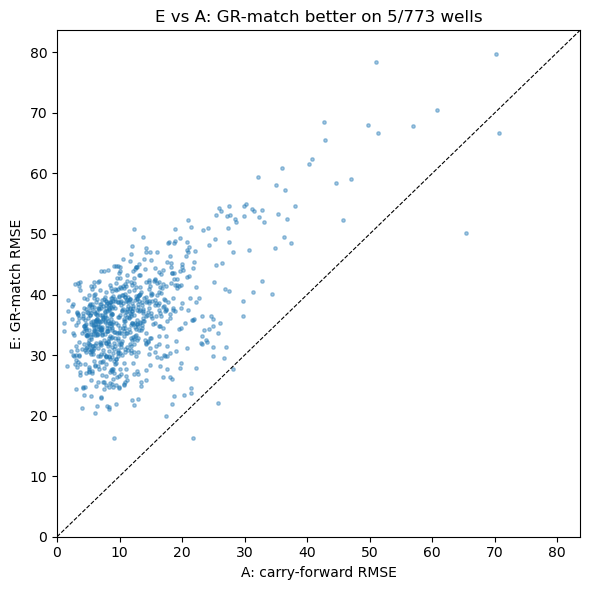

Top 5 wells where E beats A by the most:
                  A          E      delta
well                                     
a959858c  65.358659  50.224460 -15.134199
99529c45  21.675545  16.268700  -5.406846
1b1eba53  70.639375  66.733887  -3.905487
ee0300f7  25.680311  22.123645  -3.556666
ab112491  28.204037  27.708552  -0.495485

Top 5 wells where E loses to A by the most:
                  A          E      delta
well                                     
61f27424   2.815001  41.667595  38.852594
2f8e53c3   3.293055  41.966292  38.673237
2b547943  12.241457  50.798412  38.556955
2be5c96a   3.661859  42.051871  38.390012
d24ff243   3.584580  41.333958  37.749378


In [12]:
# Head-to-head: per-well A vs E. Below the y=x line means GR-match beats carry-forward on that well.
joined = (res_A.set_index('well')['rmse'].rename('A').to_frame()
          .join(res_E.set_index('well')['rmse'].rename('E')))
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(joined['A'], joined['E'], s=6, alpha=0.4)
lim_hi = max(joined['A'].max(), joined['E'].max()) * 1.05
ax.plot([0, lim_hi], [0, lim_hi], 'k--', lw=0.8)
ax.set_xlim(0, lim_hi); ax.set_ylim(0, lim_hi)
ax.set_xlabel('A: carry-forward RMSE'); ax.set_ylabel('E: GR-match RMSE')
n_wins = int((joined['E'] < joined['A']).sum())
ax.set_title(f'E vs A: GR-match better on {n_wins}/{len(joined)} wells')
plt.tight_layout(); plt.show()

# Where the two methods most disagree
joined['delta'] = joined['E'] - joined['A']  # negative = E better
print('Top 5 wells where E beats A by the most:')
print(joined.nsmallest(5, 'delta'))
print('\nTop 5 wells where E loses to A by the most:')
print(joined.nlargest(5, 'delta'))

## 6. Submission

If anything in this notebook beats A on pooled RMSE, write a fresh submission. Otherwise note that A still
holds and skip the write.

In [13]:
# Recompute test typewells (only 3, no need to cache).
test_tw = {f.name.replace('__typewell.csv', ''): pd.read_csv(f)
           for f in sorted(TEST_DIR.glob('*__typewell.csv'))}
print(f'Test typewells loaded: {list(test_tw.keys())}')

# Read sample_submission for canonical row ordering
ss = pd.read_csv(DATA / 'sample_submission.csv')
ID_COL, VAL_COL = ss.columns[0], ss.columns[1]

BASELINES = {
    'A_carry_forward':                                          (predict_carry_forward,                                       rmse_A),
    f'D_smooth_anchor_K{best_K_anchor}':                        (make_smooth_anchor(best_K_anchor),                            rmse_D),
    'E_gr_match_W51_R50_S11':                                   (lambda g, tw: predict_gr_match(g, tw, 51, 50.0, 11),          rmse_E),
}
best_name = min(BASELINES, key=lambda k: BASELINES[k][1])
best_fn, best_rmse_val = BASELINES[best_name]
print(f'\nBest by validation pooled RMSE: {best_name} ({best_rmse_val:.3f})')

if best_rmse_val < rmse_A - 1e-6:   # strict beat
    predictions: dict[str, float] = {}
    for f in sorted(TEST_DIR.glob('*__horizontal_well.csv')):
        well = f.name.replace('__horizontal_well.csv', '')
        g = pd.read_csv(f)
        g['row_idx'] = np.arange(len(g))
        tw = test_tw.get(well)
        pred = best_fn(g, tw)
        eval_mask = g[COL_TVT_INPUT].isna().values
        for i in np.where(eval_mask)[0]:
            predictions[f'{well}_{i}'] = float(pred[i])
    out = ss.copy()
    out[VAL_COL] = out[ID_COL].map(predictions)
    n_missing = int(out[VAL_COL].isna().sum())
    print(f'Missing predictions: {n_missing} / {len(out)}')
    if n_missing == 0:
        sub_path = SUB_DIR / f'03_{best_name}.csv'
        out.to_csv(sub_path, index=False)
        print(f'Saved: {sub_path}')
        print(out.head())
    else:
        print('Investigate missing rows before uploading:')
        print(out[out[VAL_COL].isna()].head())
else:
    print(f'Nothing beat A (carry-forward, RMSE {rmse_A:.3f}). No new submission written.')

Test typewells loaded: ['000d7d20', '00bbac68', '00e12e8b']

Best by validation pooled RMSE: A_carry_forward (15.910)
Nothing beat A (carry-forward, RMSE 15.910). No new submission written.


## 7. Findings + next steps

*Fill in after running.*

- **Best baseline:** ___, pooled RMSE ___
- **D vs A:** smoothed anchor changed pooled RMSE by ___ (best K = ___). Conclusion: ___
- **E vs A:** GR-match changed pooled RMSE by ___. Beats A on ___ / 773 wells.
- **Where E wins:** the top-5-by-delta wells from §5 — what do those have in common? (TVT changes a lot in
  the eval zone? GR has clear formation-transition pattern? Long eval zone?)
- **Where E loses:** the top-5-by-positive-delta wells — what's confusing the matcher? (Noisy GR? Multiple
  TVT regions with similar GR signature? Eval zone extending beyond typewell coverage?)

**If E beat A:**
- Tune E more carefully (wider sweep, joint W/R/S optimization).
- Try shrinkage: predicted TVT = α * GR_match + (1-α) * anchor. Fit α on train data.
- Use the GR-match cosine similarity itself as a confidence: when similarity is low, trust the anchor.

**If E didn't beat A (or barely tied):**
- The wells where TVT really changes are the only place E could win. If they're rare, pooled RMSE won't move
  much. Look at per-well wins, not just pooled.
- Try a *change-point* formulation: keep A's prediction by default, but switch to GR-match only when the
  lateral GR diverges from the typewell GR at the anchor TVT.
- Consider DTW (dynamic time warping) instead of pointwise window matching — handles formation transitions
  more gracefully.

**Phase-3+ directions still on the table (regardless of E's outcome):**
1. **Surface-prediction regression.** Train a regressor on `(X, Y, Z, MD, GR)` -> the six surface-elevation
   columns using train data, then derive TVT from the predicted surface position at each test row. This is
   the train-only auxiliary supervision channel we haven't touched yet.
2. **Global ML.** XGBoost/LightGBM on engineered features (distance-from-boundary, local GR stats, surface
   predictions, GR-match output as a feature). Cross-well grouped k-fold.
3. **Sequence models.** LSTM/Transformer over the well sequence with the typewell as context. Defer until
   the simpler approaches plateau.

**Reusable from this notebook:**
- `evaluate_baseline(predict_fn, train_df, typewells)` is now the canonical harness — every Phase-3+ method
  plugs in here.
- `train_tw` cache (~10s on first build, instant after) lives at `cache/train_typewells.pkl`.
- `predict_gr_match` is parameterized — drop in different `(window, search_radius, smooth)` to iterate.